In [4]:
pip install astroquery 

Note: you may need to restart the kernel to use updated packages.


In [5]:

from astroquery.sdss import SDSS
import matplotlib.pyplot as plt
import numpy as np



In [126]:


# Example: Querying the PhotoObj table for specific coordinates
query = """SELECT TOP 500000 ra, dec, u, g, r, i, z, petroR50_r, petroR90_r, type
            FROM PhotoObj 
            WHERE  type = 3 AND petroR50_r > 0 AND petroR90_r > 0 AND z<.1 AND  u >-9000 AND r > -9000"""
data = SDSS.query_sql(query, data_release=17)




print(result)

       ra               dec            u     ... petror50_r petroR90_r type
---------------- ------------------ -------- ... ---------- ---------- ----
22.4497504938385 -0.967031094521642  24.0513 ...   1.623245   3.121672    3
66.4181174233685    22.681578646938 23.24054 ...   1.220398   2.376178    3
66.3007546310427   22.6959144931441   23.397 ...  0.6576246   1.724525    3
  329.0103431255   19.3847933386599 19.79487 ...   3.328618   9.374954    3
329.013743928929   19.3826019807583 20.58367 ...  0.8855466   2.013552    3
329.011301697378   19.3870900833372 20.12675 ...   3.227594   7.820988    3
329.013093003648   19.3791683881293  23.6826 ...   1.113031   2.502381    3
82.8350952302565   9.54500772878535 28.43516 ...   1.750849   3.238658    3
82.8968719262711   9.52619202432813 12.88978 ...   2.272379   4.945389    3
329.021350555604   19.3754126764998 22.68832 ...    1.55719   6.445578    3
             ...                ...      ... ...        ...        ...  ...
193.57465307

In [127]:
data['color'] = data['u'] - data['r']
data['concentration'] = data['petroR90_r'] / data['petroR50_r']

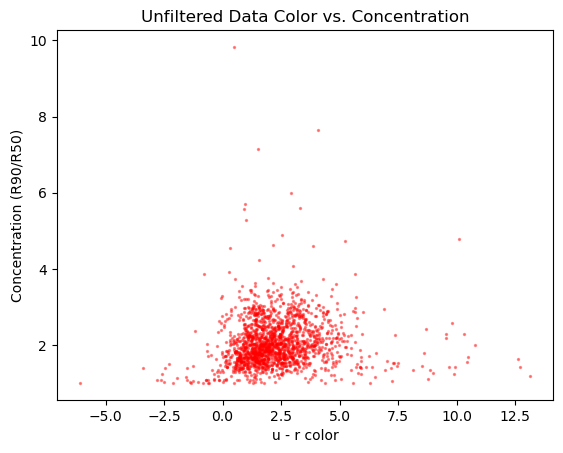

In [160]:
plt.title("Unfiltered Data Color vs. Concentration")
plt.xlabel('u - r color')
plt.ylabel('Concentration (R90/R50)')
plt.scatter(data['color'], data['concentration'],s=2 , alpha = .4, c = 'r')

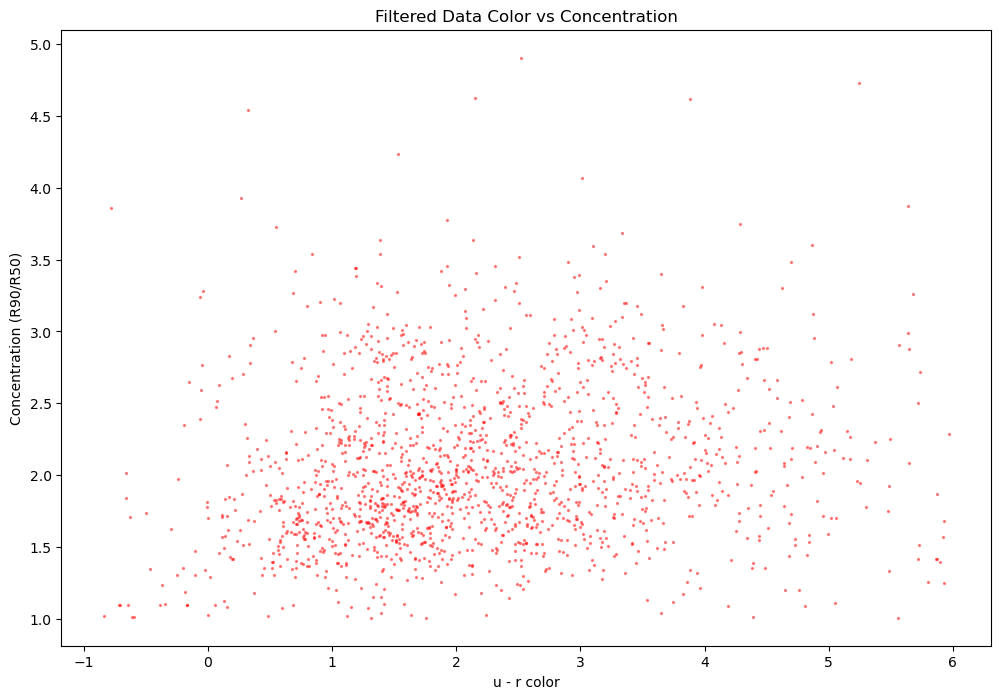

In [159]:
clean_index = np.where((data['color'] > -1 )& (data['color']<6)&( data['concentration'] <5))[0]
plt.figure(figsize=(12, 8))  

plt.title("Filtered Data Color vs Concentration")
plt.xlabel('u - r color')
plt.ylabel('Concentration (R90/R50)')
plt.scatter(data['color'][clean_index], data['concentration'][clean_index], s=2 , alpha = .4, c = 'r')

In [155]:

#plt.hist2d(data['color'][clean_index], data['concentration'][clean_index], bins=100, cmap='RdPu')

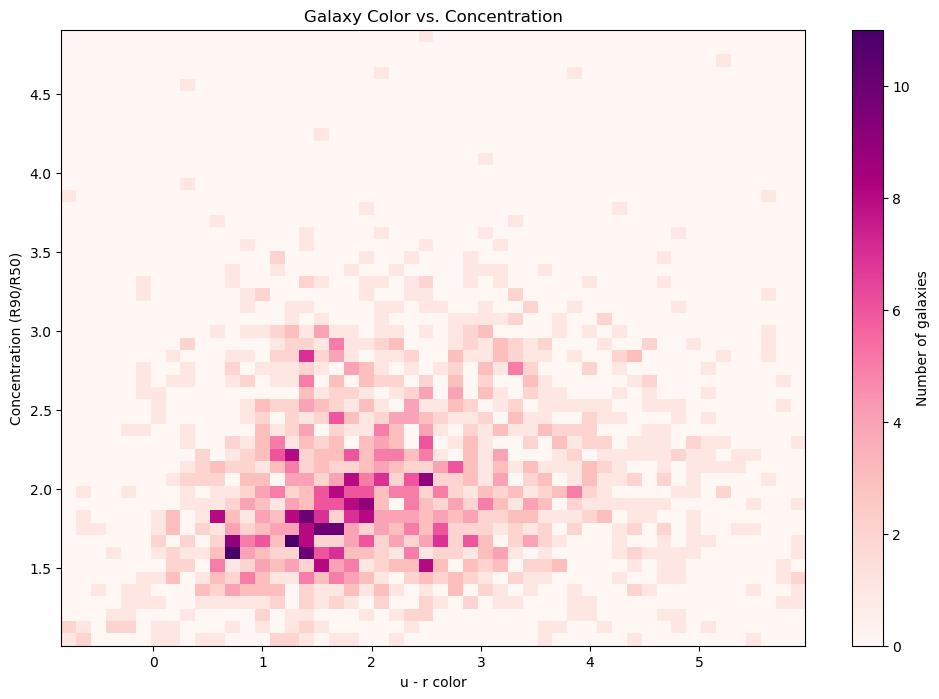

In [131]:
plt.figure(figsize=(12, 8))
plt.hist2d(data['color'][clean_index], data['concentration'][clean_index], bins=50, cmap='RdPu')
plt.colorbar(label='Number of galaxies')
plt.xlabel('u - r color')
plt.ylabel('Concentration (R90/R50)')
plt.title('Galaxy Color vs. Concentration')
plt.show()


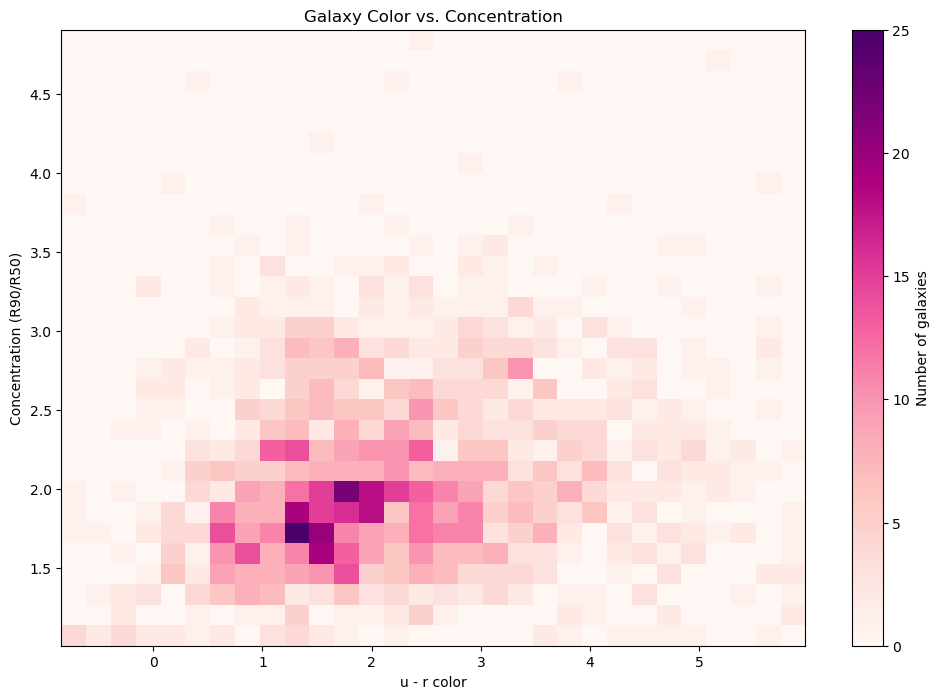

In [132]:
plt.figure(figsize=(12, 8))
plt.hist2d(data['color'][clean_index], data['concentration'][clean_index], bins=30, cmap='RdPu')
plt.colorbar(label='Number of galaxies')
plt.xlabel('u - r color')
plt.ylabel('Concentration (R90/R50)')
plt.title('Galaxy Color vs. Concentration')
plt.show()


Text(0, 0.5, 'Number of galaxies')

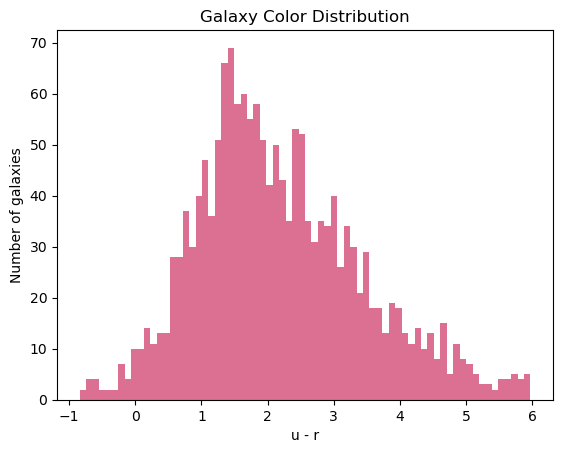

In [154]:
plt.hist(data['color'][clean_index], bins=70, color = 'palevioletred')
plt.xlabel('u - r')
plt.title('Galaxy Color Distribution')

plt.ylabel('Number of galaxies')

Text(0, 0.5, 'Number of galaxies')

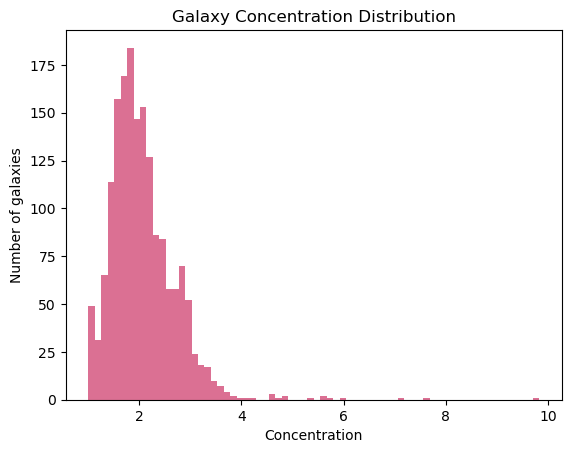

In [153]:
plt.hist(data['concentration'], bins=70, color = 'palevioletred')
plt.title('Galaxy Concentration Distribution')
plt.xlabel('Concentration')
plt.ylabel('Number of galaxies')

In [135]:
np.corrcoef(data['concentration'][clean_index], data['color'][clean_index])

array([[1.        , 0.15213259],
       [0.15213259, 1.        ]])

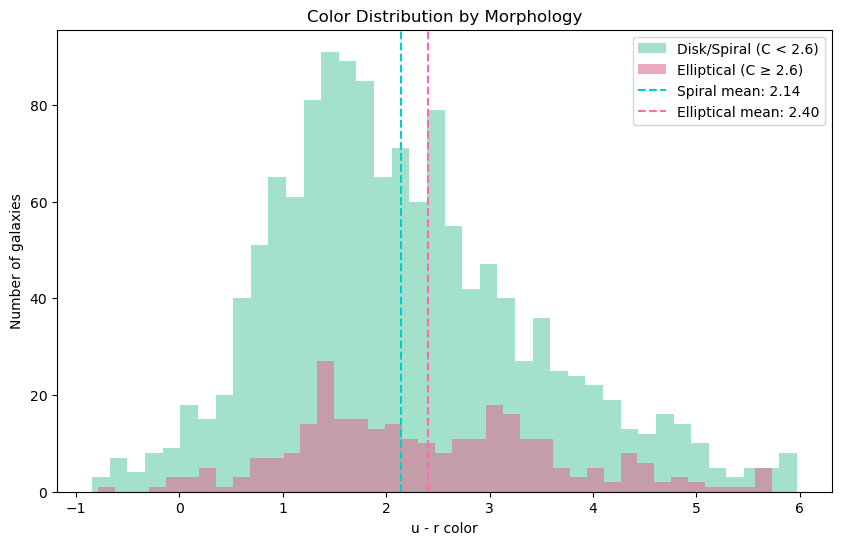

In [161]:
spiral_approx = (data['concentration'][clean_index] < 2.6)
elliptical_approx = (data['concentration'][clean_index] >= 2.6)

colors_all = data['color'][clean_index]

plt.figure(figsize=(10, 6))
plt.hist(colors_all[spiral_mask], bins=40, alpha=0.6, label='Disk/Spiral (C < 2.6)', color='mediumaquamarine')
plt.hist(colors_all[elliptical_mask], bins=40, alpha=0.6, label='Elliptical (C ≥ 2.6)', color='palevioletred')
plt.xlabel('u - r color')
plt.ylabel('Number of galaxies')
plt.title('Color Distribution by Morphology')

plt.axvline(colors_all[spiral_approx].mean(), color='darkturquoise', linestyle='--', label=f'Spiral mean: {colors_all[spiral_approx].mean():.2f}')
plt.axvline(colors_all[elliptical_approx].mean(), color='hotpink', linestyle='--', label=f'Elliptical mean: {colors_all[elliptical_approx].mean():.2f}')
plt.legend()
